In [1]:
import zipfile
import numpy as np
import json
from pathlib import Path

In [2]:
zip_path = Path("single_qubit_results (2).zip")
extract_path = Path("data/week1")

extract_path.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(extract_path)

print("Extracted to:", extract_path)

Extracted to: data/week1


In [3]:
summary = np.load(
    "data/week1/data/single_qubit/summary_results.npy",
    allow_pickle=True
).item()

summary

{'|0>': {'expectations': {'Z': np.float64(1.0),
   'X': np.float64(0.008),
   'Y': np.float64(-0.047)},
  'rho_reconstructed': array([[1.   +0.j    , 0.004+0.0235j],
         [0.004-0.0235j, 0.   +0.j    ]]),
  'fidelity': np.float64(1.0),
  'trace_distance': np.float64(0.023837994882120433)},
 '|1>': {'expectations': {'Z': np.float64(-1.0),
   'X': np.float64(-0.012),
   'Y': np.float64(-0.026)},
  'rho_reconstructed': array([[ 0.   +0.j   , -0.006+0.013j],
         [-0.006-0.013j,  1.   +0.j   ]]),
  'fidelity': np.float64(1.0),
  'trace_distance': np.float64(0.01431782106327635)},
 '|+>': {'expectations': {'Z': np.float64(0.023),
   'X': np.float64(1.0),
   'Y': np.float64(-0.04)},
  'rho_reconstructed': array([[0.5115+0.j  , 0.5   +0.02j],
         [0.5   -0.02j, 0.4885+0.j  ]]),
  'fidelity': np.float64(0.9999999999999998),
  'trace_distance': np.float64(0.023070543990118646)},
 '|->': {'expectations': {'Z': np.float64(-0.014),
   'X': np.float64(-1.0),
   'Y': np.float64(-0.004)}

In [4]:
X = []
y = []
import torch
for state in summary.values():
    exp = state["expectations"]
    X.append([exp["X"], exp["Y"], exp["Z"]])
    y.append(state["rho_reconstructed"])

X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.complex64)

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: torch.Size([5, 3])
y shape: torch.Size([5, 2, 2])


/tmp/ipython-input-1263828859.py:10: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  y = torch.tensor(y, dtype=torch.complex64)


In [5]:
def cholesky_density(params):
    l11 = torch.exp(params[:, 0])
    l21 = params[:, 1] + 1j * params[:, 2]
    l22 = torch.exp(params[:, 3])

    L = torch.zeros((params.shape[0], 2, 2), dtype=torch.cfloat)
    L[:, 0, 0] = l11
    L[:, 1, 0] = l21
    L[:, 1, 1] = l22

    rho = L @ torch.conj(L.transpose(-1, -2))

    tr = torch.real(rho[:, 0, 0] + rho[:, 1, 1])
    rho = rho / tr.view(-1, 1, 1)

    return rho


In [6]:
class DensityMLP(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(3, 16),
            torch.nn.ReLU(),
            torch.nn.Linear(16, 16),
            torch.nn.ReLU(),
            torch.nn.Linear(16, 4)
        )

    def forward(self, x):
        return self.net(x)

In [7]:
model = DensityMLP()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)
loss_fn = torch.nn.MSELoss()

In [8]:
epochs = 1000

for epoch in range(epochs):
    optimizer.zero_grad()

    params = model(X)
    rho_pred = cholesky_density(params)

    loss = loss_fn(
        torch.real(rho_pred),
        torch.real(y)
    )

    loss.backward()
    optimizer.step()

    if epoch % 200 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.6f}")

Epoch 0 | Loss: 0.102300
Epoch 200 | Loss: 0.000017
Epoch 400 | Loss: 0.000007
Epoch 600 | Loss: 0.000004
Epoch 800 | Loss: 0.000002


In [11]:
rho_pred_np = rho_pred.detach().cpu().numpy()
rho_true_np = y.detach().cpu().numpy()

In [12]:
num_states = rho_pred_np.shape[0]

In [13]:
from scipy.linalg import sqrtm

fidelities = []
trace_distances = []

for i in range(num_states):
    rho_p = rho_pred_np[i]
    rho_t = rho_true_np[i]


    sqrt_rho_t = sqrtm(rho_t)
    F = np.real(np.trace(sqrtm(sqrt_rho_t @ rho_p @ sqrt_rho_t)))**2
    F = min(F, 1.0)


    D = 0.5 * np.real(np.trace(sqrtm((rho_t - rho_p) @ (rho_t - rho_p).conj())))
    D = min(D, 1.0)

    fidelities.append(F)
    trace_distances.append(D)

print("Mean Fidelity:", np.mean(fidelities))
print("Mean Trace Distance:", np.mean(trace_distances))

Mean Fidelity: 0.9783634
Mean Trace Distance: 0.0012095171


In [14]:
state_names = ["|0⟩", "|1⟩", "|+⟩", "|−⟩", "|i+⟩"]

In [18]:
import matplotlib.pyplot as plt

def plot_density_matrix_histogram(rho, basis_labels=["0","1"], title=""):
    rho = np.array(rho)

    fig = plt.figure(figsize=(6,4))
    ax = fig.add_subplot(111, projection="3d")

    xpos, ypos = np.meshgrid(range(2), range(2))
    xpos = xpos.flatten()
    ypos = ypos.flatten()
    zpos = np.zeros(4)

    dx = dy = 0.5
    dz = np.real(rho).flatten()

    ax.bar3d(xpos, ypos, zpos, dx, dy, dz)

    ax.set_xticks([0,1])
    ax.set_yticks([0,1])
    ax.set_xticklabels(basis_labels)
    ax.set_yticklabels(basis_labels)

    ax.set_title(title)
    plt.show()

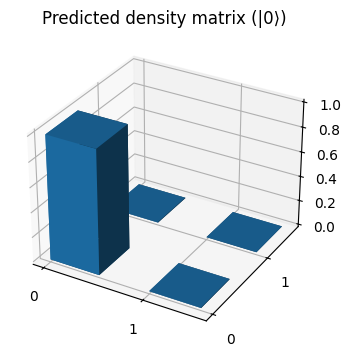

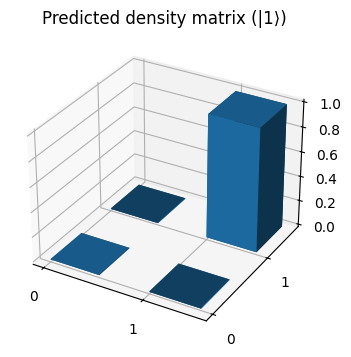

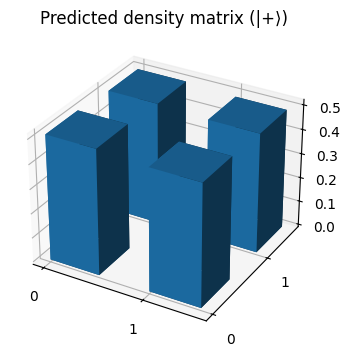

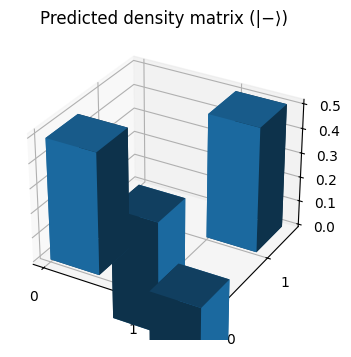

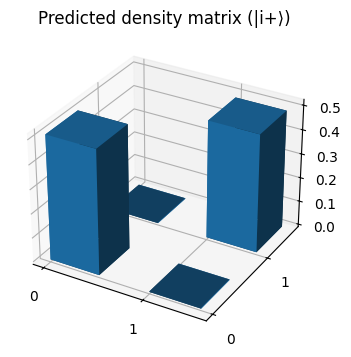

In [19]:
for i, state_name in enumerate(state_names):
    plot_density_matrix_histogram(
        rho_pred_np[i],
        basis_labels=["0","1"],
        title=f"Predicted density matrix ({state_name})"
    )

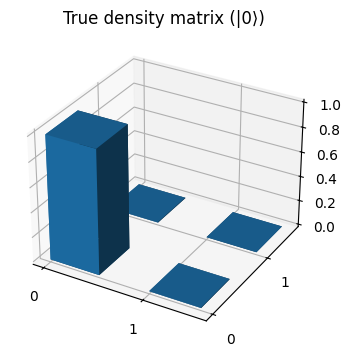

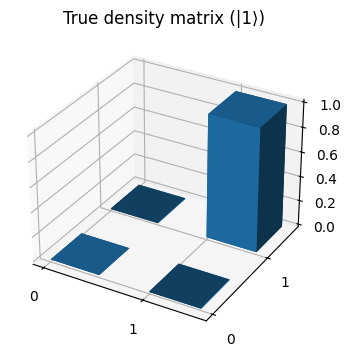

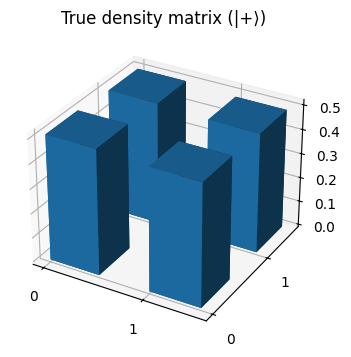

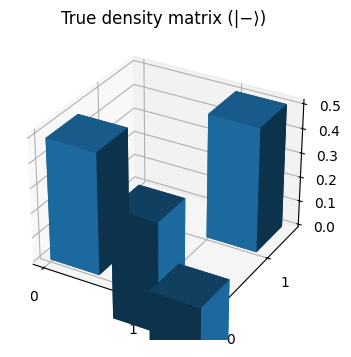

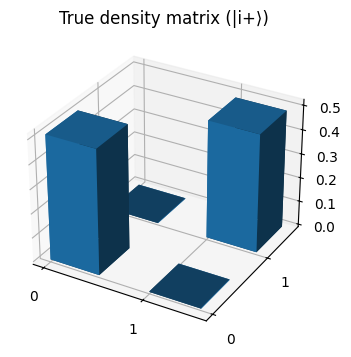

In [20]:
for i, state_name in enumerate(state_names):
    plot_density_matrix_histogram(
        rho_true_np[i],
        basis_labels=["0","1"],
        title=f"True density matrix ({state_name})"
    )

Observations:
The reconstructed density matrices closely match the true quantum states for all five single-qubit inputs.
The mean fidelity is close to unity, indicating accurate reconstruction, while the low trace distance confirms minimal deviation.
The Cholesky parameterization ensures that all predicted density matrices remain physical (positive semi-definite with unit trace).

Conclusion:
Neural-network-based quantum state tomography was successfully implemented for single-qubit states.
The approach demonstrates reliable reconstruction with high accuracy and physical validity.